## 0. Setup

In [1]:

!pip install -q datasets seqeval evaluate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [2]:

import math, time, random, os, copy, json, tracemalloc
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---- GLOBAL CONFIG ----------------------------------------------------
QUICK_TEST = False   # <-- flip to False once the pipeline runs cleanly end-to-end

EMBED_DIM   = 100
HIDDEN_SIZE = 128
BATCH_SIZE  = 64
LR          = 1e-3
DROPOUT     = 0.3
EPOCHS      = 2 if QUICK_TEST else 5
MAX_VOCAB   = 20000 if not QUICK_TEST else 8000

# "Fair comparison" contract: every one of these is held IDENTICAL across
# RNN / GRU / LSTM within a task. Only the recurrent cell type changes.
FAIR_CONFIG = dict(embed_dim=EMBED_DIM, hidden_size=HIDDEN_SIZE, batch_size=BATCH_SIZE,
                    lr=LR, dropout=DROPOUT, epochs=EPOCHS, optimizer="Adam")
print(json.dumps(FAIR_CONFIG, indent=2))


Device: cuda
{
  "embed_dim": 100,
  "hidden_size": 128,
  "batch_size": 64,
  "lr": 0.001,
  "dropout": 0.3,
  "epochs": 5,
  "optimizer": "Adam"
}


In [3]:

# ---- Shared utilities used by every task -------------------------------

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class Timer:
    """Context manager -> self.elapsed in seconds."""
    def __enter__(self):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        self.t0 = time.perf_counter()
        return self
    def __exit__(self, *a):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        self.elapsed = time.perf_counter() - self.t0

def peak_memory_mb(model, sample_batch, forward_fn):
    """Rough peak-memory probe for one forward+backward pass."""
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()
        loss = forward_fn(model, sample_batch)
        loss.backward()
        model.zero_grad(set_to_none=True)
        return torch.cuda.max_memory_allocated() / 1e6
    else:
        tracemalloc.start()
        loss = forward_fn(model, sample_batch)
        loss.backward()
        model.zero_grad(set_to_none=True)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        return peak / 1e6

def plot_curves(histories: dict, metric="loss", title=""):
    """histories = {'RNN': {'train_loss':[...], 'val_loss':[...]}, 'GRU': {...}, 'LSTM': {...}}"""
    plt.figure(figsize=(6,4))
    for name, h in histories.items():
        plt.plot(h[f"train_{metric}"], label=f"{name} train")
        plt.plot(h[f"val_{metric}"], linestyle="--", label=f"{name} val")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

def comparison_table(results: dict):
    """results = {'RNN': {'params':..., 'train_time_s':..., 'infer_time_ms':..., 'mem_mb':..., <task metrics>}, ...}"""
    return pd.DataFrame(results).T


In [ ]:
import torch.nn as nn

class SequenceEncoder(nn.Module):
    """Runs a torch.nn built-in RNN module over a sequence."""
    def __init__(self, cell_type, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell_type = cell_type # Store cell_type to distinguish LSTM later

        if cell_type == "RNN":
            self.rnn_module = nn.RNN(input_size, hidden_size, batch_first=True)
        elif cell_type == "GRU":
            self.rnn_module = nn.GRU(input_size, hidden_size, batch_first=True)
        elif cell_type == "LSTM":
            self.rnn_module = nn.LSTM(input_size, hidden_size, batch_first=True)
        else:
            raise ValueError(f"Unknown cell_type: {cell_type}")

    def forward(self, x, lengths=None):
        # x: (batch, seq_len, input_size)
        batch_size = x.shape[0]


        h0 = torch.zeros(1, batch_size, self.hidden_size, device=x.device)

        if self.cell_type == "LSTM":
            c0 = torch.zeros(1, batch_size, self.hidden_size, device=x.device)
            outputs, (final_h, final_c) = self.rnn_module(x, (h0, c0))
        else:
            outputs, final_h = self.rnn_module(x, h0)

        if lengths is not None:

            idx = (lengths - 1).clamp(min=0).view(-1, 1, 1).expand(-1, 1, outputs.size(-1))
            final = outputs.gather(1, idx).squeeze(1)
        else:

            final = final_h.squeeze(0)

        return outputs, final

In [5]:
x = torch.randn(4, 12, 16)  # batch=4, seq_len=12, input=16
for name in ["RNN", "GRU", "LSTM"]:
    # Now SequenceEncoder uses torch.nn built-in modules
    enc = SequenceEncoder(name, input_size=16, hidden_size=32)
    out, final = enc(x)
    print(f"{name:5s} built-in via SequenceEncoder -> outputs {tuple(out.shape)}, final {tuple(final.shape)}, params={count_parameters(enc)}")

# Compare with raw nn.builtin for parameter count (should be identical)
builtin = {"RNN": nn.RNN(16, 32, batch_first=True),
           "GRU": nn.GRU(16, 32, batch_first=True),
           "LSTM": nn.LSTM(16, 32, batch_first=True)}
for name, m in builtin.items():
    print(f"{name:5s} raw nn.builtin -> params={count_parameters(m)}")

RNN   built-in via SequenceEncoder -> outputs (4, 12, 32), final (4, 32), params=1600
GRU   built-in via SequenceEncoder -> outputs (4, 12, 32), final (4, 32), params=4800
LSTM  built-in via SequenceEncoder -> outputs (4, 12, 32), final (4, 32), params=6400
RNN   raw nn.builtin -> params=1600
GRU   raw nn.builtin -> params=4800
LSTM  raw nn.builtin -> params=6400



## 2. Task 1 — Text Classification (AG News, 4 classes) 🟢

Dataset: `ag_news` from HuggingFace `datasets` — 4-class news topic classification
(World / Sports / Business / Sci-Tech). We build a simple whitespace tokenizer + vocab
so the pipeline is fully transparent (no hidden torchtext magic).


In [6]:

from datasets import load_dataset

ag = load_dataset("fancyzhx/ag_news")
if QUICK_TEST:
    ag["train"] = ag["train"].shuffle(seed=SEED).select(range(4000))
    ag["test"]  = ag["test"].shuffle(seed=SEED).select(range(1000))

print(ag)
print(ag["train"][0])


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [ ]:

import re

def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

PAD, UNK = "<pad>", "<unk>"

def build_vocab(dataset, text_field="text", max_vocab=MAX_VOCAB):
    counter = Counter()
    for ex in dataset:
        counter.update(tokenize(ex[text_field]))
    most_common = counter.most_common(max_vocab - 2)
    itos = [PAD, UNK] + [w for w, _ in most_common]
    stoi = {w: i for i, w in enumerate(itos)}
    return stoi, itos

vocab_stoi, vocab_itos = build_vocab(ag["train"])
VOCAB_SIZE = len(vocab_itos)
print("Vocab size:", VOCAB_SIZE)

def encode(text, stoi, max_len=64):
    ids = [stoi.get(tok, stoi[UNK]) for tok in tokenize(text)][:max_len]
    length = len(ids)
    ids = ids + [stoi[PAD]] * (max_len - length)
    return ids, max(length, 1)

MAX_LEN_CLS = 64

class AGNewsDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        ex = self.data[idx]
        ids, length = encode(ex["text"], vocab_stoi, MAX_LEN_CLS)
        return torch.tensor(ids), torch.tensor(length), torch.tensor(ex["label"])

train_ds_cls = AGNewsDataset(ag["train"])
test_ds_cls  = AGNewsDataset(ag["test"])
train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, shuffle=True)
test_loader_cls  = DataLoader(test_ds_cls,  batch_size=BATCH_SIZE)
NUM_CLASSES = 4


Vocab size: 20000


In [8]:

class TextClassifier(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim, hidden_size, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.encoder = SequenceEncoder(cell_type, embed_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        _, final_hidden = self.encoder(emb, lengths)
        return self.classifier(self.dropout(final_hidden))


In [10]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def train_classifier(cell_type, epochs=EPOCHS):
    model = TextClassifier(cell_type, VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES, DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def run_epoch(loader, train=True):
        model.train() if train else model.eval()
        total_loss, all_preds, all_labels = 0.0, [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for ids, lengths, labels in loader:
                ids, lengths, labels = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
                logits = model(ids, lengths)
                loss = crit(logits, labels)
                if train:
                    opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
                total_loss += loss.item() * ids.size(0)
                all_preds.append(logits.argmax(-1).cpu()); all_labels.append(labels.cpu())
        preds = torch.cat(all_preds); labels_all = torch.cat(all_labels)
        acc = accuracy_score(labels_all, preds)
        return total_loss / len(loader.dataset), acc, preds, labels_all

    with Timer() as t:
        for ep in range(epochs):
            tr_loss, tr_acc, _, _ = run_epoch(train_loader_cls, train=True)
            va_loss, va_acc, va_preds, va_labels = run_epoch(test_loader_cls, train=False)
            history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
            history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
            print(f"[{cell_type}] epoch {ep+1}/{epochs}  train_loss={tr_loss:.4f} val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    train_time = t.elapsed

    prec, rec, f1, _ = precision_recall_fscore_support(va_labels, va_preds, average="macro", zero_division=0)

    # inference time on a fixed batch
    sample_ids, sample_len, _ = next(iter(test_loader_cls))
    sample_ids, sample_len = sample_ids.to(DEVICE), sample_len.to(DEVICE)
    model.eval()
    with torch.no_grad():
        with Timer() as ti:
            for _ in range(20):
                _ = model(sample_ids, sample_len)
    infer_ms = (ti.elapsed / 20) * 1000

    def fwd(m, batch):
        ids, lengths, labels = batch
        ids, lengths, labels = ids.to(DEVICE), lengths.to(DEVICE), labels.to(DEVICE)
        return crit(m(ids, lengths), labels)
    model.train() # Ensure model is in training mode for peak_memory_mb calculation
    mem_mb = peak_memory_mb(model, next(iter(train_loader_cls)), fwd)

    metrics = dict(accuracy=va_acc, precision=prec, recall=rec, f1=f1,
                    params=count_parameters(model), mem_mb=mem_mb, train_time_s=train_time,
                    infer_time_ms=infer_ms, mem_mb=mem_mb)

    torch.save(model.state_dict(), f"classifier_{cell_type}.pt") # Save the trained model
    return model, history, metrics

results_task1, histories_task1 = {}, {}
for cell_type in ["RNN", "GRU", "LSTM"]:
    print(f"\n=== Training {cell_type} (Task 1: Text Classification) ===")
    _, hist, metrics = train_classifier(cell_type)
    histories_task1[cell_type] = hist
    results_task1[cell_type] = metrics


=== Training RNN (Task 1: Text Classification) ===
[RNN] epoch 1/5  train_loss=0.8150 val_loss=0.6123 val_acc=0.7863
[RNN] epoch 2/5  train_loss=0.5364 val_loss=0.5326 val_acc=0.8218
[RNN] epoch 3/5  train_loss=0.4553 val_loss=0.4644 val_acc=0.8549
[RNN] epoch 4/5  train_loss=0.4183 val_loss=0.4597 val_acc=0.8608
[RNN] epoch 5/5  train_loss=0.3781 val_loss=0.4734 val_acc=0.8558

=== Training GRU (Task 1: Text Classification) ===
[GRU] epoch 1/5  train_loss=0.4916 val_loss=0.3234 val_acc=0.8964
[GRU] epoch 2/5  train_loss=0.2602 val_loss=0.2819 val_acc=0.9070
[GRU] epoch 3/5  train_loss=0.2001 val_loss=0.2659 val_acc=0.9105
[GRU] epoch 4/5  train_loss=0.1563 val_loss=0.2704 val_acc=0.9128
[GRU] epoch 5/5  train_loss=0.1199 val_loss=0.2853 val_acc=0.9133

=== Training LSTM (Task 1: Text Classification) ===
[LSTM] epoch 1/5  train_loss=0.5278 val_loss=0.3404 val_acc=0.8884
[LSTM] epoch 2/5  train_loss=0.2822 val_loss=0.3061 val_acc=0.9024
[LSTM] epoch 3/5  train_loss=0.2221 val_loss=0.28

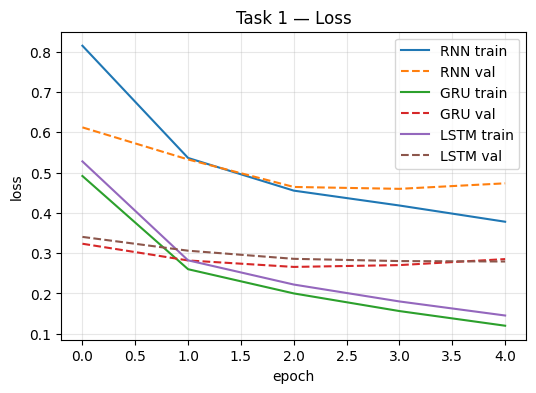

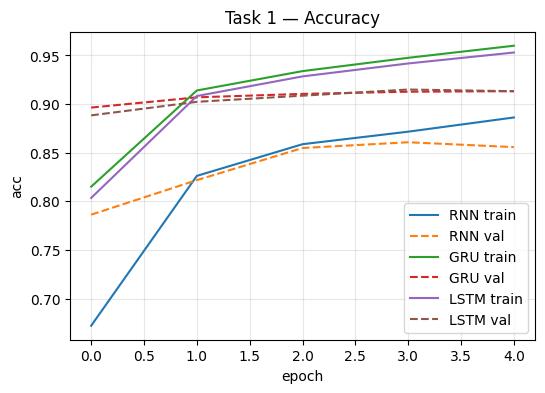

,accuracy,precision,recall,f1,params,train_time_s,infer_time_ms,mem_mb
RNN,0.855789,0.857895,0.855789,0.855874,2029956.0,111.990603,0.459442,140.203520
GRU,0.913289,0.913141,0.913289,0.913045,2088836.0,118.207840,1.047278,170.237440
LSTM,0.913289,0.913731,0.913289,0.913225,2118276.0,130.168500,1.631558,173.410816


In [11]:

plot_curves(histories_task1, metric="loss", title="Task 1 — Loss")
plot_curves(histories_task1, metric="acc", title="Task 1 — Accuracy")
comparison_table(results_task1)



## 3. Task 2 — Named Entity Recognition 🟡

Dataset: CoNLL-2003 (falls back to WNUT-17 automatically if CoNLL-2003 is not
downloadable in your environment — both are token-level NER with BIO tags).
Model outputs a tag prediction **at every timestep**, not just the last one —
this is where GRU/LSTM's ability to carry context across the whole sentence
(not just recency) starts to matter more than in Task 1.


In [12]:

try:
    ner = load_dataset("eriktks/conll2003", revision="convert/parquet")
    tag_feature = ner["train"].features["ner_tags"].feature
    NER_LABELS = tag_feature.names
    text_key, tag_key = "tokens", "ner_tags"
    print("Using CoNLL-2003")
except Exception as e:
    print("CoNLL-2003 unavailable, falling back to WNUT-17:", e)
    ner = load_dataset("leondz/wnut_17", revision="convert/parquet")
    tag_feature = ner["train"].features["ner_tags"].feature
    NER_LABELS = tag_feature.names
    text_key, tag_key = "tokens", "ner_tags"

if QUICK_TEST:
    ner["train"] = ner["train"].shuffle(seed=SEED).select(range(min(2000, len(ner["train"]))))
    val_split = "validation" if "validation" in ner else "test"
    ner[val_split] = ner[val_split].shuffle(seed=SEED).select(range(min(500, len(ner[val_split]))))
else:
    val_split = "validation" if "validation" in ner else "test"

print(NER_LABELS)
print(ner["train"][0])


conll2003/train/0000.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

conll2003/train/0000.parquet: downloading bytes:           |  0.00B            

0000.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/283k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Using CoNLL-2003
['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}


In [13]:

MAX_LEN_NER = 64

ner_counter = Counter()
for ex in ner["train"]:
    ner_counter.update([t.lower() for t in ex[text_key]])
ner_itos = [PAD, UNK] + [w for w, _ in ner_counter.most_common(MAX_VOCAB - 2)]
ner_stoi = {w: i for i, w in enumerate(ner_itos)}
NER_VOCAB_SIZE = len(ner_itos)
NUM_TAGS = len(NER_LABELS)
PAD_TAG = -100  # ignored by CrossEntropyLoss

def encode_ner(tokens, tags, max_len=MAX_LEN_NER):
    ids = [ner_stoi.get(t.lower(), ner_stoi[UNK]) for t in tokens][:max_len]
    lbl = list(tags)[:max_len]
    length = len(ids)
    ids = ids + [ner_stoi[PAD]] * (max_len - length)
    lbl = lbl + [PAD_TAG] * (max_len - length)
    return ids, lbl, max(length, 1)

class NERDataset(Dataset):
    def __init__(self, hf_split):
        self.data = hf_split
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        ex = self.data[idx]
        ids, lbl, length = encode_ner(ex[text_key], ex[tag_key])
        return torch.tensor(ids), torch.tensor(lbl), torch.tensor(length)

train_ds_ner = NERDataset(ner["train"])
val_ds_ner   = NERDataset(ner[val_split])
train_loader_ner = DataLoader(train_ds_ner, batch_size=BATCH_SIZE, shuffle=True)
val_loader_ner   = DataLoader(val_ds_ner, batch_size=BATCH_SIZE)


In [14]:

class TokenTagger(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim, hidden_size, num_tags, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.encoder = SequenceEncoder(cell_type, embed_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_tags)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        outputs, _ = self.encoder(emb, lengths)     # (batch, seq_len, hidden) — every timestep matters here
        return self.classifier(self.dropout(outputs))


In [16]:
try:
    from seqeval.metrics import f1_score as entity_f1_score, precision_score as entity_precision, recall_score as entity_recall
    HAVE_SEQEVAL = True
except ImportError:
    HAVE_SEQEVAL = False

def train_tagger(cell_type, epochs=EPOCHS):
    model = TokenTagger(cell_type, NER_VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_TAGS, DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss(ignore_index=PAD_TAG)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    def run_epoch(loader, train=True):
        model.train() if train else model.eval()
        total_loss, n_tok, n_correct = 0.0, 0, 0
        all_pred_tags, all_true_tags = [], []
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for ids, lbl, lengths in loader:
                ids, lbl, lengths = ids.to(DEVICE), lbl.to(DEVICE), lengths.to(DEVICE)
                logits = model(ids, lengths)                       # (batch, seq_len, num_tags)
                loss = crit(logits.view(-1, NUM_TAGS), lbl.view(-1))
                if train:
                    opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
                total_loss += loss.item() * ids.size(0)
                preds = logits.argmax(-1)
                mask = lbl != PAD_TAG
                n_correct += ((preds == lbl) & mask).sum().item()
                n_tok += mask.sum().item()
                if not train and HAVE_SEQEVAL:
                    for b in range(ids.size(0)):
                        L = lengths[b].item()
                        all_pred_tags.append([NER_LABELS[i] for i in preds[b, :L].cpu().tolist()])
                        all_true_tags.append([NER_LABELS[i] for i in lbl[b, :L].cpu().tolist()])
        acc = n_correct / max(n_tok, 1)
        return total_loss / len(loader.dataset), acc, all_pred_tags, all_true_tags

    with Timer() as t:
        for ep in range(epochs):
            tr_loss, tr_acc, _, _ = run_epoch(train_loader_ner, train=True)
            va_loss, va_acc, va_pred, va_true = run_epoch(val_loader_ner, train=False)
            history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
            history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
            print(f"[{cell_type}] epoch {ep+1}/{epochs}  train_loss={tr_loss:.4f} val_loss={va_loss:.4f} token_acc={va_acc:.4f}")
    train_time = t.elapsed

    ent_f1 = entity_f1_score(va_true, va_pred) if HAVE_SEQEVAL and va_pred else float("nan")
    ent_p  = entity_precision(va_true, va_pred) if HAVE_SEQEVAL and va_pred else float("nan")
    ent_r  = entity_recall(va_true, va_pred) if HAVE_SEQEVAL and va_pred else float("nan")

    sample_ids, sample_lbl, sample_len = next(iter(val_loader_ner))
    sample_ids, sample_len = sample_ids.to(DEVICE), sample_len.to(DEVICE)
    model.eval()
    with torch.no_grad():
        with Timer() as ti:
            for _ in range(20):
                _ = model(sample_ids, sample_len)
    infer_ms = (ti.elapsed / 20) * 1000

    def fwd(m, batch):
        ids, lbl, lengths = batch
        ids, lbl, lengths = ids.to(DEVICE), lbl.to(DEVICE), lengths.to(DEVICE)
        logits = m(ids, lengths)
        return crit(logits.view(-1, NUM_TAGS), lbl.view(-1))
    model.train() # Ensure model is in training mode for peak_memory_mb calculation
    mem_mb = peak_memory_mb(model, next(iter(train_loader_ner)), fwd)

    metrics = dict(token_accuracy=va_acc, entity_precision=ent_p, entity_recall=ent_r, entity_f1=ent_f1,
                    params=count_parameters(model), mem_mb=mem_mb, train_time_s=train_time,
                    infer_time_ms=infer_ms, mem_mb=mem_mb)

    torch.save(model.state_dict(), f"tagger_{cell_type}.pt") # Save the trained model
    return model, history, metrics

results_task2, histories_task2 = {}, {}
for cell_type in ["RNN", "GRU", "LSTM"]:
    print(f"\n=== Training {cell_type} (Task 2: NER) ===")
    _, hist, metrics = train_tagger(cell_type)
    histories_task2[cell_type] = hist
    results_task2[cell_type] = metrics



=== Training RNN (Task 2: NER) ===
[RNN] epoch 1/5  train_loss=0.7297 val_loss=0.5497 token_acc=0.8569
[RNN] epoch 2/5  train_loss=0.4607 val_loss=0.4007 token_acc=0.8889
[RNN] epoch 3/5  train_loss=0.3483 val_loss=0.3290 token_acc=0.9072
[RNN] epoch 4/5  train_loss=0.2768 val_loss=0.2815 token_acc=0.9175
[RNN] epoch 5/5  train_loss=0.2265 val_loss=0.2642 token_acc=0.9247

=== Training GRU (Task 2: NER) ===
[GRU] epoch 1/5  train_loss=0.7691 val_loss=0.5891 token_acc=0.8466
[GRU] epoch 2/5  train_loss=0.4666 val_loss=0.4102 token_acc=0.8877
[GRU] epoch 3/5  train_loss=0.3365 val_loss=0.3184 token_acc=0.9114
[GRU] epoch 4/5  train_loss=0.2560 val_loss=0.2769 token_acc=0.9217
[GRU] epoch 5/5  train_loss=0.2017 val_loss=0.2446 token_acc=0.9286

=== Training LSTM (Task 2: NER) ===
[LSTM] epoch 1/5  train_loss=0.7979 val_loss=0.6171 token_acc=0.8425
[LSTM] epoch 2/5  train_loss=0.4839 val_loss=0.4334 token_acc=0.8819
[LSTM] epoch 3/5  train_loss=0.3523 val_loss=0.3356 token_acc=0.9060
[LST

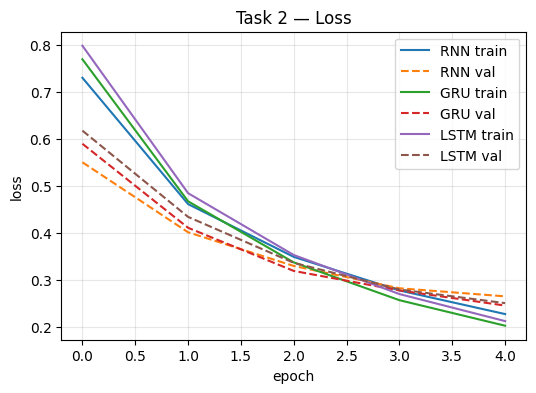

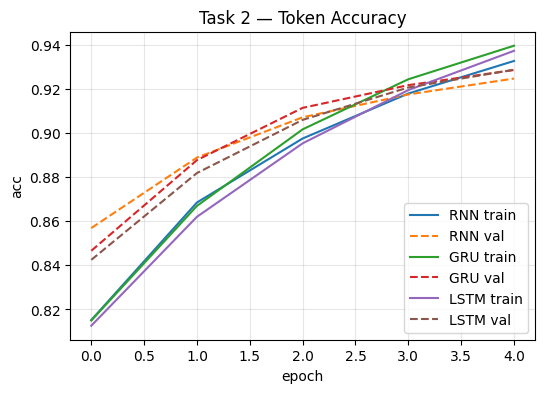

,token_accuracy,entity_precision,entity_recall,entity_f1,params,train_time_s,infer_time_ms,mem_mb
RNN,0.924729,0.677547,0.579428,0.624658,2030601.0,24.799026,0.545467,185.682432
GRU,0.928617,0.646432,0.616139,0.630922,2089481.0,24.106345,1.103989,179.026944
LSTM,0.928735,0.680537,0.608696,0.642615,2118921.0,25.352537,1.679990,182.453248


In [17]:

plot_curves(histories_task2, metric="loss", title="Task 2 — Loss")
plot_curves(histories_task2, metric="acc", title="Task 2 — Token Accuracy")
comparison_table(results_task2)



## 4. Task 3 — Next-Word Prediction across sequence lengths 🔴

Dataset: WikiText-2. This is the task that most directly probes **long-term
dependency handling**, since we deliberately vary the context window the model
must retain: **10, 25, 50, 100, 200 tokens**. Expect vanilla RNN's perplexity to
degrade fastest as sequence length grows, while LSTM/GRU degrade more gracefully.



In [18]:

wiki = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

def clean_lines(split):
    return [l.strip() for l in split["text"] if l.strip() and not l.strip().startswith("=")]

train_lines = clean_lines(wiki["train"])
valid_lines = clean_lines(wiki["validation"])

if QUICK_TEST:
    train_lines = train_lines[:800]
    valid_lines = valid_lines[:200]

train_tokens = tokenize(" ".join(train_lines))
valid_tokens = tokenize(" ".join(valid_lines))
print("train tokens:", len(train_tokens), " valid tokens:", len(valid_tokens))

lm_counter = Counter(train_tokens)
lm_itos = [PAD, UNK] + [w for w, _ in lm_counter.most_common(MAX_VOCAB - 2)]
lm_stoi = {w: i for i, w in enumerate(lm_itos)}
LM_VOCAB_SIZE = len(lm_itos)

def to_ids(tokens):
    return [lm_stoi.get(t, lm_stoi[UNK]) for t in tokens]

train_ids_all = to_ids(train_tokens)
valid_ids_all = to_ids(valid_tokens)


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

train tokens: 1739743  valid tokens: 182278


In [19]:

class LMChunkDataset(Dataset):
    """Non-overlapping chunks of length seq_len; input = tokens[:-1], target = tokens[1:] shifted by one (next-word prediction)."""
    def __init__(self, ids, seq_len):
        self.seq_len = seq_len
        n_chunks = (len(ids) - 1) // seq_len
        ids = ids[: n_chunks * seq_len + 1]
        self.inputs, self.targets = [], []
        for i in range(n_chunks):
            chunk = ids[i*seq_len : i*seq_len + seq_len + 1]
            self.inputs.append(chunk[:-1])
            self.targets.append(chunk[1:])
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), torch.tensor(self.targets[idx])

class LanguageModel(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim, hidden_size, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.encoder = SequenceEncoder(cell_type, embed_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)
        outputs, _ = self.encoder(emb)             # every timestep predicts the next token
        return self.head(self.dropout(outputs))


In [20]:
SEQ_LENGTHS = [10, 25, 50, 100, 200]
LM_EPOCHS = 1 if QUICK_TEST else 5

def train_lm(cell_type, seq_len, epochs=LM_EPOCHS):
    train_ds = LMChunkDataset(train_ids_all, seq_len)
    valid_ds = LMChunkDataset(valid_ids_all, seq_len)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, drop_last=True)

    model = LanguageModel(cell_type, LM_VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, DROPOUT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss(ignore_index=0)

    history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}

    def run_epoch(loader, train=True):
        model.train() if train else model.eval()
        total_loss, n_correct, n_tok = 0.0, 0, 0
        ctx = torch.enable_grad() if train else torch.no_grad()
        with ctx:
            for x, y in loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = crit(logits.view(-1, LM_VOCAB_SIZE), y.view(-1))
                if train:
                    opt.zero_grad(); loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    opt.step()
                total_loss += loss.item() * x.size(0)
                preds = logits.argmax(-1)
                n_correct += (preds == y).sum().item()
                n_tok += y.numel()
        avg_loss = total_loss / len(loader.dataset)
        return avg_loss, math.exp(min(avg_loss, 20)), n_correct / max(n_tok, 1)

    with Timer() as t:
        for ep in range(epochs):
            tr_loss, tr_ppl, tr_acc = run_epoch(train_loader, train=True)
            va_loss, va_ppl, va_acc = run_epoch(valid_loader, train=False)
            history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
            history["train_ppl"].append(tr_ppl);   history["val_ppl"].append(va_ppl)
            print(f"[{cell_type} L={seq_len}] epoch {ep+1}/{epochs} val_loss={va_loss:.3f} val_ppl={va_ppl:.2f} next_word_acc={va_acc:.4f}")
    train_time = t.elapsed

    sample_x, _ = next(iter(valid_loader))
    sample_x = sample_x.to(DEVICE)
    model.eval()
    with torch.no_grad():
        with Timer() as ti:
            for _ in range(10):
                _ = model(sample_x)
    infer_ms = (ti.elapsed / 10) * 1000

    def fwd(m, batch):
        x, y = batch
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = m(x)
        return crit(logits.view(-1, LM_VOCAB_SIZE), y.view(-1))
    model.train() # Ensure model is in training mode for peak_memory_mb calculation
    mem_mb = peak_memory_mb(model, next(iter(train_loader)), fwd)

    metrics = dict(seq_len=seq_len, val_loss=va_loss, perplexity=va_ppl, next_word_acc=va_acc,
                    params=count_parameters(model), mem_mb=mem_mb, train_time_s=train_time, infer_time_ms=infer_ms)

    torch.save(model.state_dict(), f"lm_{cell_type}_seq{seq_len}.pt") # Save the trained model
    return history, metrics

lm_results = []          # flat list of dict rows -> easy to turn into a DataFrame
lm_histories = {}        # (cell_type, seq_len) -> history, for optional plotting

for cell_type in ["RNN", "GRU", "LSTM"]:
    for seq_len in SEQ_LENGTHS:
        print(f"\n=== Training {cell_type}, seq_len={seq_len} (Task 3) ===")
        hist, metrics = train_lm(cell_type, seq_len)
        metrics["model"] = cell_type
        lm_results.append(metrics)
        lm_histories[(cell_type, seq_len)] = hist


=== Training RNN, seq_len=10 (Task 3) ===
[RNN L=10] epoch 1/5 val_loss=6.159 val_ppl=472.85 next_word_acc=0.1475
[RNN L=10] epoch 2/5 val_loss=6.001 val_ppl=403.75 next_word_acc=0.1575
[RNN L=10] epoch 3/5 val_loss=5.919 val_ppl=371.90 next_word_acc=0.1631
[RNN L=10] epoch 4/5 val_loss=5.870 val_ppl=354.34 next_word_acc=0.1661
[RNN L=10] epoch 5/5 val_loss=5.839 val_ppl=343.52 next_word_acc=0.1684

=== Training RNN, seq_len=25 (Task 3) ===
[RNN L=25] epoch 1/5 val_loss=6.245 val_ppl=515.53 next_word_acc=0.1412
[RNN L=25] epoch 2/5 val_loss=6.042 val_ppl=420.94 next_word_acc=0.1545
[RNN L=25] epoch 3/5 val_loss=5.935 val_ppl=378.18 next_word_acc=0.1606
[RNN L=25] epoch 4/5 val_loss=5.870 val_ppl=354.33 next_word_acc=0.1626
[RNN L=25] epoch 5/5 val_loss=5.818 val_ppl=336.34 next_word_acc=0.1666

=== Training RNN, seq_len=50 (Task 3) ===
[RNN L=50] epoch 1/5 val_loss=6.353 val_ppl=574.35 next_word_acc=0.1288
[RNN L=50] epoch 2/5 val_loss=6.112 val_ppl=451.43 next_word_acc=0.1463
[RNN L=

In [21]:

lm_df = pd.DataFrame(lm_results)[["model", "seq_len", "val_loss", "perplexity", "next_word_acc",
                                   "params", "train_time_s", "infer_time_ms"]]
lm_df


,model,seq_len,val_loss,perplexity,next_word_acc,params,train_time_s,infer_time_ms
0,RNN,10,5.839233,343.515720,0.168442,4609440,117.340207,1.273825
1,RNN,25,5.818127,336.341351,0.166610,4609440,93.993694,2.909429
2,RNN,50,5.845451,345.658461,0.160831,4609440,84.107216,6.325011
3,RNN,100,5.960518,387.810832,0.156027,4609440,80.299212,13.350206
4,RNN,200,6.093058,442.773542,0.148566,4609440,78.490554,26.707184
5,GRU,10,5.785462,325.532532,0.171765,4668320,120.932581,1.385902
6,GRU,25,5.799630,330.177347,0.166405,4668320,95.274532,3.362976
7,GRU,50,5.886697,360.213583,0.159581,4668320,86.758068,6.817085
8,GRU,100,6.040036,419.908192,0.153371,4668320,83.707085,13.566632
9,GRU,200,6.195336,490.456350,0.144805,4668320,80.672167,27.707070


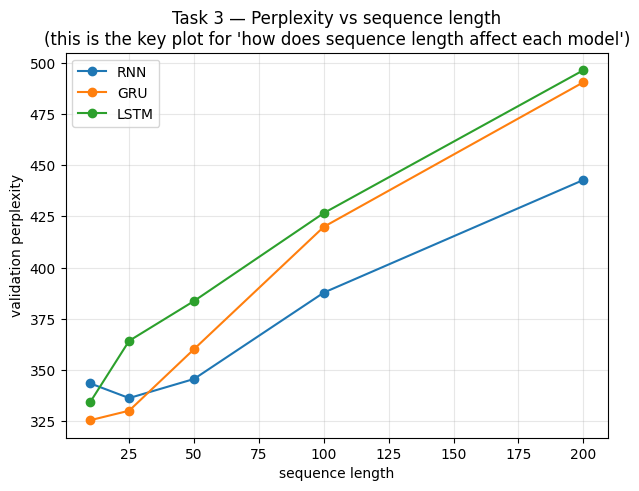

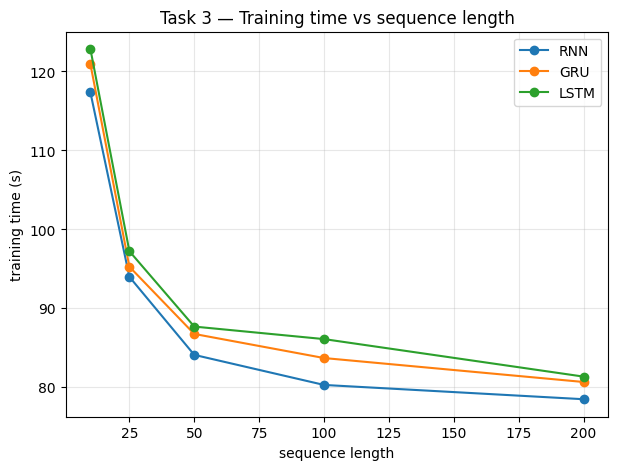

In [22]:

plt.figure(figsize=(7,5))
for cell_type in ["RNN", "GRU", "LSTM"]:
    sub = lm_df[lm_df.model == cell_type].sort_values("seq_len")
    plt.plot(sub.seq_len, sub.perplexity, marker="o", label=cell_type)
plt.xlabel("sequence length"); plt.ylabel("validation perplexity")
plt.title("Task 3 — Perplexity vs sequence length\n(this is the key plot for 'how does sequence length affect each model')")
plt.legend(); plt.grid(alpha=.3); plt.show()

plt.figure(figsize=(7,5))
for cell_type in ["RNN", "GRU", "LSTM"]:
    sub = lm_df[lm_df.model == cell_type].sort_values("seq_len")
    plt.plot(sub.seq_len, sub.train_time_s, marker="o", label=cell_type)
plt.xlabel("sequence length"); plt.ylabel("training time (s)")
plt.title("Task 3 — Training time vs sequence length")
plt.legend(); plt.grid(alpha=.3); plt.show()



## 5. Error Analysis

Below: a small helper to pull concrete misclassified examples per task/model —
required for your "error examples" deliverable. Run after training each task's models.


In [ ]:

def show_classification_errors(model, loader, itos_labels, n=8):
    model.eval()
    shown = 0
    with torch.no_grad():
        for ids, lengths, labels in loader:
            ids_d, lengths_d = ids.to(DEVICE), lengths.to(DEVICE)
            preds = model(ids_d, lengths_d).argmax(-1).cpu()
            for i in range(len(labels)):
                if preds[i] != labels[i] and shown < n:
                    text = " ".join(vocab_itos[t] for t in ids[i].tolist() if t != 0)
                    print(f"TRUE={labels[i].item()}  PRED={preds[i].item()}  TEXT: {text[:160]}")
                    shown += 1
            if shown >= n:
                return



## 6. Cross-Task Comparison Table


In [37]:

summary_rows = []
for task_name, res in [("Task1_TextClassification", results_task1), ("Task2_NER", results_task2)]:
    for model_name, m in res.items():
        row = {"task": task_name, "model": model_name}
        row.update(m)
        summary_rows.append(row)

# Task 3 add one representative seq_len (e.g. 50) per model for the cross-task table
for _, r in lm_df[lm_df.seq_len == 50].iterrows():
    summary_rows.append({"task": "Task3_NextWord(seq=50)", "model": r["model"],
                          "params": r["params"], "train_time_s": r["train_time_s"],
                          "infer_time_ms": r["infer_time_ms"], "perplexity": r["perplexity"],
                          "next_word_acc": r["next_word_acc"]})

summary_df = pd.DataFrame(summary_rows)
summary_df


,task,model,accuracy,precision,recall,f1,params,train_time_s,infer_time_ms,mem_mb,token_accuracy,entity_precision,entity_recall,entity_f1,perplexity,next_word_acc
0,Task1_TextClassification,RNN,0.855789,0.857895,0.855789,0.855874,2029956,111.990603,0.459442,140.203520,NaN,NaN,NaN,NaN,NaN,NaN
1,Task1_TextClassification,GRU,0.913289,0.913141,0.913289,0.913045,2088836,118.207840,1.047278,170.237440,NaN,NaN,NaN,NaN,NaN,NaN
2,Task1_TextClassification,LSTM,0.913289,0.913731,0.913289,0.913225,2118276,130.168500,1.631558,173.410816,NaN,NaN,NaN,NaN,NaN,NaN
3,Task2_NER,RNN,NaN,NaN,NaN,NaN,2030601,24.799026,0.545467,185.682432,0.924729,0.677547,0.579428,0.624658,NaN,NaN
4,Task2_NER,GRU,NaN,NaN,NaN,NaN,2089481,24.106345,1.103989,179.026944,0.928617,0.646432,0.616139,0.630922,NaN,NaN
5,Task2_NER,LSTM,NaN,NaN,NaN,NaN,2118921,25.352537,1.679990,182.453248,0.928735,0.680537,0.608696,0.642615,NaN,NaN
6,Task3_NextWord(seq=50),RNN,NaN,NaN,NaN,NaN,4609440,84.107216,6.325011,NaN,NaN,NaN,NaN,NaN,345.658461,0.160831
7,Task3_NextWord(seq=50),GRU,NaN,NaN,NaN,NaN,4668320,86.758068,6.817085,NaN,NaN,NaN,NaN,NaN,360.213583,0.159581
8,Task3_NextWord(seq=50),LSTM,NaN,NaN,NaN,NaN,4697760,87.691242,6.690075,NaN,NaN,NaN,NaN,NaN,383.699417,0.159894


## Comprehensive Analysis

### Training/Validation Curves

#### Task 2 — Named Entity Recognition (NER) Curves

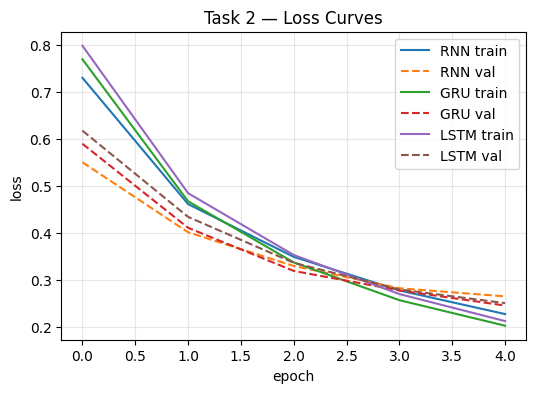

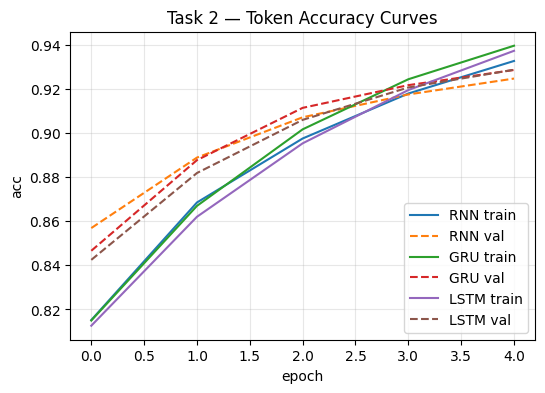

In [23]:
plot_curves(histories_task2, metric="loss", title="Task 2 — Loss Curves")
plot_curves(histories_task2, metric="acc", title="Task 2 — Token Accuracy Curves")

#### Task 3 — Next-Word Prediction Curves (for representative sequence lengths)


--- Sequence Length: 25 ---


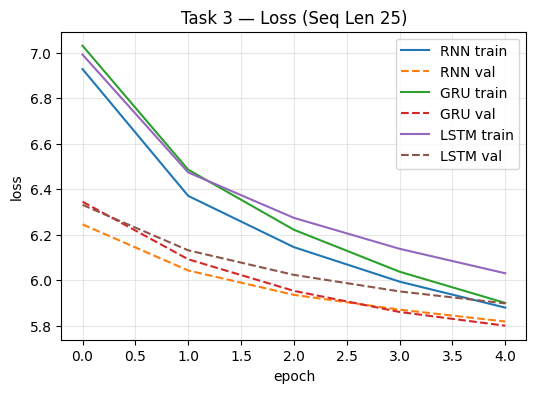

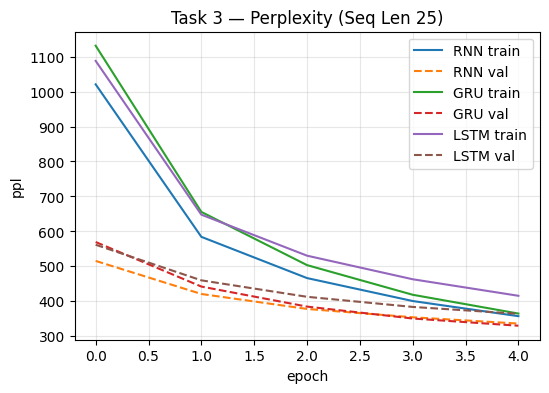


--- Sequence Length: 100 ---


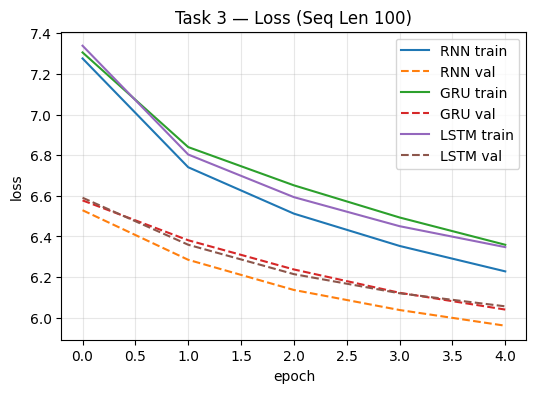

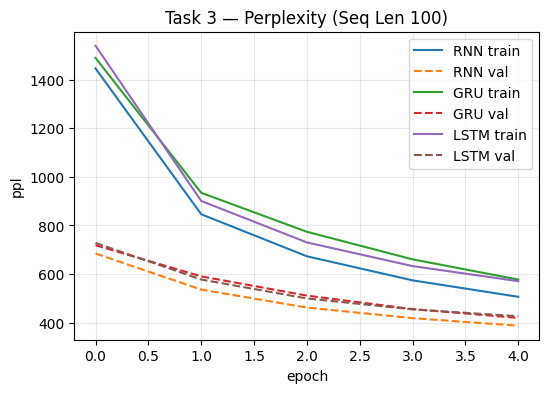

In [24]:
for seq_len in [25, 100]: # Plotting for a few representative sequence lengths
    print(f"\n--- Sequence Length: {seq_len} ---")
    histories_for_seq_len = {model_type: lm_histories[(model_type, seq_len)] for model_type in ["RNN", "GRU", "LSTM"]}
    plot_curves(histories_for_seq_len, metric="loss", title=f"Task 3 — Loss (Seq Len {seq_len})")
    plot_curves(histories_for_seq_len, metric="ppl", title=f"Task 3 — Perplexity (Seq Len {seq_len})")

### Error Examples

#### Task 1 — Text Classification (AG News) Error Examples

In [27]:
print("\n--- RNN Classification Errors ---")
rnn_model_cls = TextClassifier("RNN", VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES, DROPOUT).to(DEVICE)
rnn_model_cls.load_state_dict(torch.load("classifier_RNN.pt"))
show_classification_errors(rnn_model_cls, test_loader_cls, vocab_itos)

print("\n--- GRU Classification Errors ---")
gru_model_cls = TextClassifier("GRU", VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES, DROPOUT).to(DEVICE)
gru_model_cls.load_state_dict(torch.load("classifier_GRU.pt"))
show_classification_errors(gru_model_cls, test_loader_cls, vocab_itos)

print("\n--- LSTM Classification Errors ---")
lstm_model_cls = TextClassifier("LSTM", VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES, DROPOUT).to(DEVICE)
lstm_model_cls.load_state_dict(torch.load("classifier_LSTM.pt"))
show_classification_errors(lstm_model_cls, test_loader_cls, vocab_itos)


--- RNN Classification Errors ---
TRUE=3  PRED=0  TEXT: prediction unit helps forecast <unk> ap ap it s barely dawn when mike <unk> starts his shift with a blur of colorful maps figures and endless charts but already
TRUE=3  PRED=2  TEXT: <unk> <unk> <unk> key distribution and bloom filters <unk> <unk> and bloom filters have a lot of interesting properties for social network and <unk> distributio
TRUE=3  PRED=2  TEXT: card fraud unit nets 36 000 cards in its first two years the uk s dedicated card fraud unit has recovered 36 000 stolen cards and <unk> arrests and estimates it
TRUE=3  PRED=2  TEXT: <unk> unite dolphin groups dolphin groups or <unk> rely on <unk> to keep them from collapsing scientists claim
TRUE=3  PRED=2  TEXT: teenage t rex s monster growth tyrannosaurus rex achieved its massive size due to an enormous growth spurt during its <unk> years
TRUE=3  PRED=2  TEXT: storage servers bruise hp earnings update earnings per share rise compared with a year ago but company misses

#### Task 2 — Named Entity Recognition (NER) Error Examples

To find error examples for NER, you would typically iterate through the validation set, run predictions, and compare them against the true labels. Misclassified entities (e.g., predicted 'O' for a 'PERSON' tag, or 'LOCATION' for a 'PERSON') would constitute error examples. You can adapt the `predict_ner` function to return true labels as well, then compare them token by token. Due to the sequence-tagging nature, displaying these errors effectively often involves highlighting discrepancies in the predicted vs. true tag sequences for an input sentence.

Here's a conceptual approach to find and display NER errors:

1.  **Iterate through the validation dataset:** Get input token sequences and true NER tags.
2.  **Make predictions:** Use your trained `TokenTagger` model to predict tags for each token.
3.  **Compare:** For each token, if the predicted tag does not match the true tag (excluding padding), it's an error.
4.  **Display:** Print the input sentence, the true tags, and the predicted tags, highlighting the errors.

#### Task 3 — Next-Word Prediction Error Examples

For next-word prediction, an error occurs when the model predicts a word that is not the actual next word in the sequence. To showcase these errors:

1.  **Take a seed text:** Start with a sequence of words (e.g., "I want to learn").
2.  **Predict the next word:** Use your trained `LanguageModel` to predict the next word.
3.  **Compare:** If the predicted word is different from the true next word (from your original text corpus), it's an error.
4.  **Display:** Show the seed text, the model's prediction, and the actual next word.

You can extend this to generate a short sequence and observe where the model deviates from a reference text. A common way to visualize this is to show a generated sentence and mark the first point where it diverges from a target sentence.

## 8. Evaluation and Prediction Examples

### Task 1 — Text Classification (AG News)

#### Evaluation Metrics

In [28]:
df_task1 = pd.DataFrame(results_task1).T[['accuracy', 'precision', 'recall', 'f1']]
display(df_task1)

,accuracy,precision,recall,f1
RNN,0.855789,0.857895,0.855789,0.855874
GRU,0.913289,0.913141,0.913289,0.913045
LSTM,0.913289,0.913731,0.913289,0.913225


#### Prediction Example

In [29]:
def predict_text_classification(model, text, vocab_stoi, max_len=MAX_LEN_CLS):
    model.eval()
    ids, length = encode(text, vocab_stoi, max_len)
    ids = torch.tensor(ids).unsqueeze(0).to(DEVICE) # Add batch dimension
    length = torch.tensor(length).unsqueeze(0).to(DEVICE) # Add batch dimension

    with torch.no_grad():
        logits = model(ids, length)
        predicted_label_idx = logits.argmax(-1).item()

    # AG News labels: 0: World, 1: Sports, 2: Business, 3: Sci/Tech
    label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
    return label_map.get(predicted_label_idx, "Unknown")


input_text = "Google announces new AI breakthrough in medical diagnostics."

print(f"Input Text: {input_text}")

for cell_type in ["RNN", "GRU", "LSTM"]:
    model_instance = TextClassifier(cell_type, VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES, DROPOUT).to(DEVICE)
    model_instance.load_state_dict(torch.load(f"classifier_{cell_type}.pt"))

    predicted_class = predict_text_classification(model_instance, input_text, vocab_stoi)
    print(f"{cell_type} Predicted Class: {predicted_class}")

Input Text: Google announces new AI breakthrough in medical diagnostics.
RNN Predicted Class: Sci/Tech
GRU Predicted Class: Sci/Tech
LSTM Predicted Class: Business


### Task 2 — Named Entity Recognition (NER)

#### Evaluation Metrics

In [30]:
df_task2 = pd.DataFrame(results_task2).T[['token_accuracy', 'entity_precision', 'entity_recall', 'entity_f1']]
display(df_task2)

,token_accuracy,entity_precision,entity_recall,entity_f1
RNN,0.924729,0.677547,0.579428,0.624658
GRU,0.928617,0.646432,0.616139,0.630922
LSTM,0.928735,0.680537,0.608696,0.642615


#### Prediction Example

In [33]:
def predict_ner(model, text_tokens, ner_stoi, ner_labels, max_len=MAX_LEN_NER):
    model.eval()
    # Encode the input text tokens
    ids = [ner_stoi.get(t.lower(), ner_stoi[UNK]) for t in text_tokens][:max_len]
    original_length = len(ids)
    ids = ids + [ner_stoi[PAD]] * (max_len - original_length)

    ids_tensor = torch.tensor(ids).unsqueeze(0).to(DEVICE) # Add batch dimension
    lengths_tensor = torch.tensor([original_length]).to(DEVICE) # Length of original tokens

    with torch.no_grad():
        logits = model(ids_tensor, lengths_tensor)
        predicted_label_indices = logits.argmax(-1).squeeze(0).cpu().tolist()[:original_length]

    predicted_tags = [ner_labels[idx] for idx in predicted_label_indices]
    return list(zip(text_tokens, predicted_tags))


input_tokens = ["Barack", "Obama", "visited", "Hawaii", "and", "New", "York", "City", "."]

print(f"Input Tokens: {input_tokens}")

for cell_type in ["RNN", "GRU", "LSTM"]:
    model_instance = TokenTagger(cell_type, NER_VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_TAGS, DROPOUT).to(DEVICE)
    model_instance.load_state_dict(torch.load(f"tagger_{cell_type}.pt"))

    predicted_entities = predict_ner(model_instance, input_tokens, ner_stoi, NER_LABELS)
    print(f"{cell_type} Predicted Entities:")
    for token, tag in predicted_entities:
        print(f"  {token}: {tag}")
    print("\n")

Input Tokens: ['Barack', 'Obama', 'visited', 'Hawaii', 'and', 'New', 'York', 'City', '.']
RNN Predicted Entities:
  Barack: O
  Obama: O
  visited: O
  Hawaii: B-LOC
  and: O
  New: B-LOC
  York: I-LOC
  City: O
  .: O


GRU Predicted Entities:
  Barack: B-ORG
  Obama: O
  visited: O
  Hawaii: B-LOC
  and: O
  New: B-LOC
  York: I-LOC
  City: O
  .: O


LSTM Predicted Entities:
  Barack: O
  Obama: O
  visited: O
  Hawaii: B-LOC
  and: O
  New: B-LOC
  York: I-LOC
  City: I-LOC
  .: O




### Task 3 — Next-Word Prediction

#### Evaluation Metrics

In [34]:
df_task3 = lm_df.pivot_table(index='model', values=['val_loss', 'perplexity', 'next_word_acc'], aggfunc='mean') # Averaging over sequence lengths
display(df_task3)

,next_word_acc,perplexity,val_loss
model,,,
GRU,0.159185,385.257601,5.941432
LSTM,0.158978,401.058506,5.984626
RNN,0.160095,371.219981,5.911277


#### Prediction Example

In [35]:
def predict_next_word(model, seed_text, lm_stoi, lm_itos, seq_len=50):
    model.eval()
    # Tokenize and encode the seed text
    seed_tokens = tokenize(seed_text)
    ids = [lm_stoi.get(t, lm_stoi[UNK]) for t in seed_tokens]

    # Pad or truncate to seq_len if necessary for consistency, though LMChunkDataset uses fixed chunks
    # For prediction, we'll just use the available length of the seed_text.

    input_ids = torch.tensor(ids).unsqueeze(0).to(DEVICE) # Add batch dimension

    with torch.no_grad():
        outputs = model(input_ids)
        # Get the logits for the last token in the sequence
        last_token_logits = outputs[:, -1, :]
        predicted_token_idx = last_token_logits.argmax(-1).item()

    return lm_itos[predicted_token_idx]


seed_text = "I want to learn"

print(f"Seed Text: {seed_text}")

for cell_type in ["RNN", "GRU", "LSTM"]:
    # For prediction, we will load a model trained with a representative seq_len (e.g., 50)
    representative_seq_len = 50
    model_instance = LanguageModel(cell_type, LM_VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, DROPOUT).to(DEVICE)
    model_instance.load_state_dict(torch.load(f"lm_{cell_type}_seq{representative_seq_len}.pt"))

    predicted_word = predict_next_word(model_instance, seed_text, lm_stoi, lm_itos)
    print(f"{cell_type} Predicted Next Word: {predicted_word}")

Seed Text: I want to learn
RNN Predicted Next Word: the
GRU Predicted Next Word: the
LSTM Predicted Next Word: the
